# OTUS | CMS DoubleElectron with MG5 $Z/\gamma^*$ Prior

This notebook trains OTUS using CMS Open Data DoubleElectron events as detector-level data `x`, and a standalone MadGraph5 pre-detector Drell--Yan `pp -> e+ e-` prior as latent/theory-level data `z`.

Expected `z` HDF5 file layout:

```text
FDL/zData : shape (N, 8)
columns   : [e- px, e- py, e- pz, e- E, e+ px, e+ py, e+ pz, e+ E]
```

Put the MG5 HDF5 file in the same folder as this notebook, or set `theory_prior_file` to its full path in the meta-parameter cell.


# Load Required Libraries

In [1]:
%matplotlib inline
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import torch
import uproot

import sys
from pathlib import Path

import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# Change this to your actual OTUS root folder
OTUS_ROOT = Path(r"C:\Users\AhrixMarin\Desktop\otus")
UTILITY_DIR = OTUS_ROOT / "utilityFunctions"
assert (UTILITY_DIR / "func_utils.py").exists(), f"Cannot find func_utils.py in {UTILITY_DIR}"

sys.path.insert(0, str(UTILITY_DIR))

print("Using utilityFunctions from:", UTILITY_DIR)

#-- Determine if using GPU or CPU --#
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Set to '-1' to disable GPU

from configs import device

print('Using device:', device)

Matplotlib is building the font cache; this may take a moment.


AssertionError: Cannot find func_utils.py in C:\Users\AhrixMarin\Desktop\otus/utilityFunctions

# Meta Parameters

In [3]:
cms_root_file = Path('../cms_zpeak/data/Run2012B_DoubleElectron.root')

# MG5 prior produced on Linux and copied to this notebook folder.
# Change this filename if your HDF5 file has a different name.
theory_prior_filename = 'cms_dyee_mg5_8tev_dy1j_ptj5_fiducial_70_110.hdf5'
theory_prior_file = Path(theory_prior_filename)

# Used only for saved model/results filenames.
dataset_name = 'cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v3_fullproduction'

#-- Set random seeds --#
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

#-- Set data type --#
from configs import float_type
print('Using data type:', float_type)
print('Notebook/kernel working directory:', Path.cwd())
print('Expected MG5 prior file:', theory_prior_file)
print('Local .hdf5 files:', sorted([p.name for p in Path('.').glob('*.hdf5')]))


Using data type: float32
Notebook/kernel working directory: c:\Users\AhrixMarin\Desktop\otus\experiments\cms_doubleelectron
Expected MG5 prior file: cms_dyee_mg5_8tev_dy1j_ptj5_fiducial_70_110.hdf5
Local .hdf5 files: ['cms_dyee_mg5_8tev_dy1j_ptj5_fiducial_70_110.hdf5', 'cms_dyee_mg5_8tev_fiducial_70_110.hdf5']


# Load CMS DoubleElectron ROOT File

In [4]:
assert cms_root_file.exists(), f'File not found: {cms_root_file.resolve()}'

cms_file = uproot.open(cms_root_file)
events = cms_file['Events']

print('File:', cms_root_file.resolve())
print('Number of events:', events.num_entries)

electron_branches = [k for k in events.keys() if 'Electron' in k]
electron_branches[:30]

File: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012B_DoubleElectron.root
Number of events: 21474287


['nElectron',
 'Electron_pt',
 'Electron_eta',
 'Electron_phi',
 'Electron_mass',
 'Electron_charge',
 'Electron_pfRelIso03_all',
 'Electron_dxy',
 'Electron_dxyErr',
 'Electron_dz',
 'Electron_dzErr']

In [5]:
branches = [
    'nElectron',
    'Electron_pt',
    'Electron_eta',
    'Electron_phi',
    'Electron_mass',
    'Electron_charge',
    'Electron_pfRelIso03_all',
    'Electron_dxy',
    'Electron_dz',
]

arrays = events.arrays(branches, library='ak')

print('Loaded events:', len(arrays['nElectron']))
print('Example nElectron values:', arrays['nElectron'][:10])

Loaded events: 21474287
Example nElectron values: [0, 1, 2, 2, 1, 2, 0, 2, 1, 0]


# Select Good Electron Pairs

In [6]:
# Basic kinematic cuts
electron_pt_min = 20.0
electron_abs_eta_max = 2.5

# Electron quality cuts
electron_iso_max = 0.15
electron_dxy_max = 0.05
electron_dz_max = 0.10

# Z-window cut
z_mass_min = 70.0
z_mass_max = 110.0

electrons = ak.zip({
    'pt': arrays['Electron_pt'],
    'eta': arrays['Electron_eta'],
    'phi': arrays['Electron_phi'],
    'mass': arrays['Electron_mass'],
    'charge': arrays['Electron_charge'],
    'pfRelIso03_all': arrays['Electron_pfRelIso03_all'],
    'dxy': arrays['Electron_dxy'],
    'dz': arrays['Electron_dz'],
})

abs_eta = np.abs(electrons.eta)
outside_ecal_gap = ~((abs_eta > 1.4442) & (abs_eta < 1.566))

selected_electrons = electrons[
    (electrons.pt > electron_pt_min)
    & (abs_eta < electron_abs_eta_max)
    & outside_ecal_gap
    & (electrons.pfRelIso03_all < electron_iso_max)
    & (np.abs(electrons.dxy) < electron_dxy_max)
    & (np.abs(electrons.dz) < electron_dz_max)
]

print('Total selected electrons:', ak.sum(ak.num(selected_electrons)))
print('Events with >=2 selected electrons:', ak.sum(ak.num(selected_electrons) >= 2))

pairs = ak.combinations(selected_electrons, 2, fields=['e1', 'e2'])
os_pairs = pairs[(pairs.e1.charge * pairs.e2.charge) < 0]

e_minus = ak.where(os_pairs.e1.charge < 0, os_pairs.e1, os_pairs.e2)
e_plus = ak.where(os_pairs.e1.charge > 0, os_pairs.e1, os_pairs.e2)

def pair_mass(first, second):
    px = first.pt * np.cos(first.phi) + second.pt * np.cos(second.phi)
    py = first.pt * np.sin(first.phi) + second.pt * np.sin(second.phi)
    pz = first.pt * np.sinh(first.eta) + second.pt * np.sinh(second.eta)
    e1 = np.sqrt((first.pt * np.cosh(first.eta)) ** 2 + first.mass ** 2)
    e2 = np.sqrt((second.pt * np.cosh(second.eta)) ** 2 + second.mass ** 2)
    mass2 = (e1 + e2) ** 2 - px ** 2 - py ** 2 - pz ** 2
    return np.sqrt(ak.where(mass2 > 0, mass2, 0))

m_ee = pair_mass(e_minus, e_plus)
z_window = (m_ee > z_mass_min) & (m_ee < z_mass_max)

e_minus = ak.flatten(e_minus[z_window])
e_plus = ak.flatten(e_plus[z_window])
masses_ee = ak.to_numpy(ak.flatten(m_ee[z_window]))

print('Opposite-sign dielectron pairs in 70-110 GeV:', len(masses_ee))
print(f'Mean mass:   {np.mean(masses_ee):.6f} GeV')
print(f'Median mass: {np.median(masses_ee):.6f} GeV')

Total selected electrons: 9734445
Events with >=2 selected electrons: 1903393
Opposite-sign dielectron pairs in 70-110 GeV: 1344681
Mean mass:   90.638089 GeV
Median mass: 91.148434 GeV


# Build Detector-Level x-Space Array

In [7]:
def p4_array(particle):
    pt = ak.to_numpy(particle.pt)
    eta = ak.to_numpy(particle.eta)
    phi = ak.to_numpy(particle.phi)
    mass = ak.to_numpy(particle.mass)

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    energy = np.sqrt(px ** 2 + py ** 2 + pz ** 2 + mass ** 2)
    return np.stack([px, py, pz, energy], axis=1)

# Match ppzee ordering: [p_e-^mu, p_e+^mu], with p^mu = [px, py, pz, E]
x_data = np.concatenate([p4_array(e_minus), p4_array(e_plus)], axis=1)

print('x_data shape:', x_data.shape)
print('First x row:', x_data[0])

x_data shape: (1344681, 8)
First x row: [-35.98058   48.777832  35.590557  70.28917   20.748224 -27.40425
  26.977688  43.69528 ]


# Load Theory-Level z-Space Prior

In [8]:
import h5py

# Load the MadGraph5 pre-detector physics prior z from the HDF5 file.
# Expected HDF5 layout:
#   FDL/zData : shape (N, 8)
# with columns:
#   [e- px, e- py, e- pz, e- E, e+ px, e+ py, e+ pz, e+ E]

if not theory_prior_file.exists():
    available_hdf5 = sorted([p.name for p in Path('.').glob('*.hdf5')])
    print('Available .hdf5 files in current working directory:', available_hdf5)
    raise FileNotFoundError(
        f'Cannot find {theory_prior_file}. '
        'Either move the HDF5 file into the notebook folder, '
        'or set theory_prior_file to the absolute Windows path.'
    )

with h5py.File(theory_prior_file, 'r') as f:
    print('HDF5 top-level keys:', list(f.keys()))
    if 'FDL' in f and isinstance(f['FDL'], h5py.Group) and 'zData' in f['FDL']:
        z_data = np.asarray(f['FDL/zData'])
    elif 'zData' in f:
        z_data = np.asarray(f['zData'])
    else:
        raise KeyError('Could not find z prior. Expected FDL/zData or zData in the HDF5 file.')

# Keep the same 8D ordering used by x_data:
# [p_e-^mu, p_e+^mu], with p^mu = [px, py, pz, E]
z_data = z_data[:, :8]

assert x_data.ndim == 2 and x_data.shape[1] == 8, f'x_data should have shape (N, 8), got {x_data.shape}'
assert z_data.ndim == 2 and z_data.shape[1] == 8, f'z_data should have shape (N, 8), got {z_data.shape}'
assert np.all(np.isfinite(x_data)), 'x_data contains NaN or inf'
assert np.all(np.isfinite(z_data)), 'z_data contains NaN or inf'

# IMPORTANT for v3:
# Do NOT truncate CMS x to the smaller MG5 z prior.
# OTUS trains on unpaired samples x ~ p(x) and z ~ p(z), so x and z may have
# different lengths. The training loaders below independently sample both.
num_x_samples = len(x_data)
num_z_samples = len(z_data)

x_dim = int(x_data.shape[1])
z_dim = int(z_data.shape[1])

print('Loaded z prior from:', theory_prior_file)
print('x_data shape:', x_data.shape)
print('z_data shape:', z_data.shape)
print('num_x_samples used:', num_x_samples)
print('num_z_samples used:', num_z_samples)
print('CMS events kept instead of truncating:', num_x_samples)
print('First z row:', z_data[0])


HDF5 top-level keys: ['FDL']
Loaded z prior from: cms_dyee_mg5_8tev_dy1j_ptj5_fiducial_70_110.hdf5
x_data shape: (1344681, 8)
z_data shape: (623944, 8)
num_x_samples used: 1344681
num_z_samples used: 623944
CMS events kept instead of truncating: 1344681
First z row: [-29.129568 -29.58772  -46.255836  62.1576    34.138885  32.209503
 -22.410378  52.010963]


## Pre-training sanity check

Compare the CMS detector-level mass distribution with the MG5 pre-detector prior before training. The MG5 curve should usually be narrower because it does not include detector resolution, electron energy smearing, or reconstruction effects.

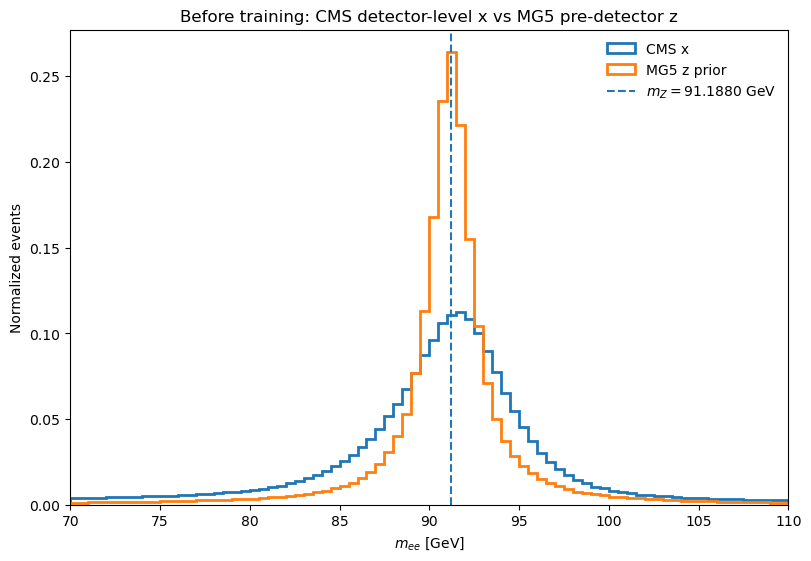

CMS x mass mean: 90.6381 GeV
MG5 z mass mean: 91.0889 GeV
CMS x mass std:  5.8542 GeV
MG5 z mass std:  4.0285 GeV


In [9]:
from func_utils import Zboson_mass

x_m_before = Zboson_mass(x_data)
z_m_before = Zboson_mass(z_data)

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
bins = np.linspace(70, 110, 81)

ax.hist(x_m_before, bins=bins, histtype='step', linewidth=2, density=True, label='CMS x')
ax.hist(z_m_before, bins=bins, histtype='step', linewidth=2, density=True, label='MG5 z prior')
ax.axvline(91.1880, linestyle='--', linewidth=1.5, label=r'$m_Z = 91.1880$ GeV')

ax.set_xlabel(r'$m_{ee}$ [GeV]')
ax.set_ylabel('Normalized events')
ax.set_xlim(70, 110)
ax.set_title('Before training: CMS detector-level x vs MG5 pre-detector z')
ax.legend(frameon=False)
plt.show()

print(f'CMS x mass mean: {np.mean(x_m_before):.4f} GeV')
print(f'MG5 z mass mean: {np.mean(z_m_before):.4f} GeV')
print(f'CMS x mass std:  {np.std(x_m_before):.4f} GeV')
print(f'MG5 z mass std:  {np.std(z_m_before):.4f} GeV')


### Define target invariant masses

In [10]:
# Electrons are treated as massless for consistency with ppzee.ipynb.
x_inv_masses = np.zeros(2)
z_inv_masses = np.zeros(2)

# Train/Test Split

In [11]:
from torch.utils.data import DataLoader

# Independent unpaired split.
# x and z do NOT need equal lengths because OTUS trains on samples from p(x)
# and p(z), not on event-level truth pairs.
def split_unpaired(arr, train_ratio=0.80, val_ratio=0.10, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(arr))
    arr = arr[perm]

    train_size = int(len(arr) * train_ratio)
    val_size = int(len(arr) * val_ratio)

    train = arr[:train_size]
    val = arr[train_size:train_size + val_size]
    test = arr[train_size + val_size:]
    return train, val, test

train_ratio = 0.80
val_ratio = 0.10

x_train, x_val, x_test = split_unpaired(x_data, train_ratio, val_ratio, seed=seed)
z_train, z_val, z_test = split_unpaired(z_data, train_ratio, val_ratio, seed=seed + 1)

x_train, x_val, x_test, z_train, z_val, z_test = list(map(
    lambda arr: arr.astype(float_type),
    [x_train, x_val, x_test, z_train, z_val, z_test],
))

x_train_mean, x_train_std = np.mean(x_train, axis=0), np.std(x_train, axis=0)
z_train_mean, z_train_std = np.mean(z_train, axis=0), np.std(z_train, axis=0)

# Protect against accidental zero std in any feature.
x_train_std = np.where(x_train_std == 0, 1.0, x_train_std)
z_train_std = np.where(z_train_std == 0, 1.0, z_train_std)

# Validation loaders are only used to monitor training loss. They do not need
# equal lengths. The final validation plots use all arrays in all_arrs.
eval_batch_size = min(HP["eval_batch_size"] if 'HP' in globals() else 20000, max(1, min(len(x_val), len(z_val))))
eval_loaders = DataLoader(dataset=x_val, batch_size=eval_batch_size, shuffle=True), \
               DataLoader(dataset=z_val, batch_size=eval_batch_size, shuffle=True)

print('x_train shape:', x_train.shape)
print('z_train shape:', z_train.shape)
print('x_val shape:', x_val.shape)
print('z_val shape:', z_val.shape)
print('x_test shape:', x_test.shape)
print('z_test shape:', z_test.shape)
print('Total CMS x kept:', len(x_data))
print('Total MG5 z kept:', len(z_data))


x_train shape: (1075744, 8)
z_train shape: (499155, 8)
x_val shape: (134468, 8)
z_val shape: (62394, 8)
x_test shape: (134469, 8)
z_test shape: (62395, 8)
Total CMS x kept: 1344681
Total MG5 z kept: 623944


# Train

## Import Training Specific Libraries and Functions

In [12]:
from torch import optim
from ppzee_utils import train_and_val

## Central hyperparameter block

Edit this one cell when tuning architecture, batch sizes, and staged training.

In [13]:
# ============================================================
# Central Hyperparameter Block -- v3
# Edit this cell when tuning the training.
# ============================================================

HP = {
    # -------------------------
    # Model architecture
    # -------------------------
    # Default: keep 2 x 256 while testing the v3 loss/stage changes.
    # Only switch architecture_preset to "3x512_plateau_retry" after the v3
    # residual summary plateaus above the target; do not change architecture
    # before checking the loss logic.
    "architecture_preset": "2x256_v3_default",   # or "3x512_plateau_retry"
    "cond_noise": True,
    "num_hidden_layers": 2,
    "dim_per_hidden_layer": 256,
    "activation": torch.nn.ReLU,
    "sigma_fun": "softplus",

    # Larger batches make the soft histogram residual less noisy.
    # If CUDA memory is tight, reduce train_batch_size back to 4096.
    "train_batch_size": 8192,
    "eval_batch_size": 50000,
    "preload_data_to_gpu": True,
    "pin_memory_if_cpu_loader": True,

    # -------------------------
    # Training stages
    # -------------------------
    # mode = "standard": original OTUS train_and_val with z_loss_with_mass.
    # mode = "observable_residual": custom decoder-focused fine-tune using
    #       soft residual-ratio losses on mll, lepton pt/eta, ptll, and yll.
    # mode = "z_cycle": frozen-decoder inverse polish z -> D(z) -> E(D(z)).
    # -------------------------
    "stages": [
        {
            "name": "stage1_anchor_warmup",
            "mode": "standard",
            "enabled": True,
            "epochs": 50,
            "lr": 1e-3,
            "beta": 1.0,
            "lamb": 1.0,
            "tau": 1.0,
            "rho": 0.0,
            "nu_e": 50.0,
            "nu_d": 50.0,
            "num_slices": 500,
            "log_freq": 10,
            "lr_decay": False,
            "freeze_encoder": False,
            "freeze_decoder": False,
        },
        {
            "name": "stage2_joint_transport",
            "mode": "standard",
            "enabled": True,
            "epochs": 100,
            "lr": 5e-4,
            "beta": 1.0,
            "lamb": 1.0,
            "tau": 1.0,
            "rho": 0.0,
            "nu_e": 0.0,
            "nu_d": 0.0,
            "num_slices": 800,
            "log_freq": 20,
            "lr_decay": True,
            "freeze_encoder": False,
            "freeze_decoder": False,
        },
        {
            "name": "stage3_decoder_response_mass_protected",
            "mode": "standard",
            "enabled": True,
            "epochs": 160,
            "lr": 1e-4,
            "beta": 0.8,
            "lamb": 1.0,
            "tau": 1.5,
            "rho": 0.0,
            "nu_e": 0.0,
            "nu_d": 0.0,
            "num_slices": 1500,
            "log_freq": 20,
            "lr_decay": True,
            "freeze_encoder": False,
            "freeze_decoder": False,
        },
        {
            "name": "stage4_soft_residual_ratio_decoder_finetune",
            "mode": "observable_residual",
            "enabled": True,
            "epochs": 80,
            "lr": 2e-5,

            # In this stage:
            # beta keeps x -> E(x) -> D(E(x)) from drifting.
            # lamb softly monitors/regularizes E(x) ~ z; encoder is frozen by default.
            # residual_ratio_weight is the new differentiable soft bin-by-bin ratio term.
            # observable_w1_weight keeps the observable shapes globally sane.
            "beta": 0.25,
            "lamb": 0.05,
            "tau": 0.0,
            "residual_ratio_weight": 0.005,
            "observable_w1_weight": 0.05,

            "rho": 0.0,
            "nu_e": 0.0,
            "nu_d": 0.0,
            "num_slices": 1000,
            "log_freq": 5,
            "lr_decay": True,
            "freeze_encoder": True,
            "freeze_decoder": False,
        },
        {
            "name": "stage5_frozen_decoder_z_cycle_inverse_polish",
            "mode": "z_cycle",
            "enabled": True,
            "epochs": 100,
            "lr": 1e-5,

            # Decoder is frozen here. This improves the inverse map only:
            # z -> frozen D(z) -> E(D(z)) should recover z.
            "beta": 1.0,
            "lamb": 2.0,
            "tau": 0.0,
            "z_cycle_weight": 4.0,
            "transverse_weight": 1.0,

            "rho": 0.0,
            "nu_e": 0.0,
            "nu_d": 0.0,
            "num_slices": 1500,
            "log_freq": 10,
            "lr_decay": False,
            "freeze_encoder": False,
            "freeze_decoder": True,
        },
        {
            "name": "stage6_optional_balanced_finetune_after_inverse_polish",
            "mode": "standard",
            "enabled": False,
            "epochs": 30,
            "lr": 5e-6,
            "beta": 1.0,
            "lamb": 1.5,
            "tau": 0.3,
            "rho": 0.0,
            "nu_e": 0.0,
            "nu_d": 0.0,
            "num_slices": 800,
            "log_freq": 10,
            "lr_decay": False,
            "freeze_encoder": False,
            "freeze_decoder": False,
        },
    ],
}

if HP["architecture_preset"] == "3x512_plateau_retry":
    HP["num_hidden_layers"] = 3
    HP["dim_per_hidden_layer"] = 512
elif HP["architecture_preset"] != "2x256_v3_default":
    raise ValueError(f"Unknown architecture_preset: {HP['architecture_preset']}")

if HP["cond_noise"]:
    from models import CondNoiseAutoencoder
    Autoencoder = CondNoiseAutoencoder
else:
    from models import Autoencoder

print('Using model class:', Autoencoder.__name__)
print('Architecture preset:', HP['architecture_preset'])
print('Hidden layers:', HP['num_hidden_layers'], 'x', HP['dim_per_hidden_layer'])
print('Enabled stages:', [s['name'] for s in HP['stages'] if s.get('enabled', True)])
print('train_batch_size:', HP['train_batch_size'])
print('eval_batch_size:', HP['eval_batch_size'])
print('preload_data_to_gpu:', HP['preload_data_to_gpu'])


Using model class: CondNoiseAutoencoder
Architecture preset: 2x256_v3_default
Hidden layers: 2 x 256
Enabled stages: ['stage1_anchor_warmup', 'stage2_joint_transport', 'stage3_decoder_response_mass_protected', 'stage4_soft_residual_ratio_decoder_finetune', 'stage5_frozen_decoder_z_cycle_inverse_polish']
train_batch_size: 8192
eval_batch_size: 50000
preload_data_to_gpu: True


## Build model from hyperparameter block

In [14]:
# ============================================================
# Build Model from HP
# ============================================================

num_hidden_layers = HP["num_hidden_layers"]
dim_per_hidden_layer = HP["dim_per_hidden_layer"]
hidden_layer_dims = num_hidden_layers * [dim_per_hidden_layer]

activation = HP["activation"]
sigma_fun = HP["sigma_fun"]

model = Autoencoder(
    x_dim=x_dim,
    z_dim=z_dim,
    hidden_layer_dims=hidden_layer_dims,
    raw_io=True,
    x_stats=np.stack([x_train_mean, x_train_std]),
    z_stats=np.stack([z_train_mean, z_train_std]),
    x_inv_masses=x_inv_masses,
    z_inv_masses=z_inv_masses,
    stoch_enc=True,
    stoch_dec=True,
    activation=activation,
    sigma_fun=sigma_fun,
)

model


CondNoiseAutoencoder(
  (encoder): CondNoiseMLP(
    (sigma_fun): Softplus(beta=1.0, threshold=20.0)
    (output_nn): Sequential(
      (0): Linear(in_features=14, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=6, bias=True)
    )
    (cond_noise_nn): Sequential(
      (0): Linear(in_features=8, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=12, bias=True)
    )
  )
  (decoder): CondNoiseMLP(
    (sigma_fun): Softplus(beta=1.0, threshold=20.0)
    (output_nn): Sequential(
      (0): Linear(in_features=14, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=6, bias=True)
    )
    (cond_noise_nn): Sequential(

In [15]:
from func_utils import sliced_wd
import torch

P = 2
EPS = 1e-6

# ----------------------------
# Internal z-loss component weights
# ----------------------------
lambda_z8 = 0.50
lambda_marginal = 0.80
lambda_mass = 1.80
lambda_phys = 0.70
lambda_transverse = 0.80
lambda_longitudinal = 0.80
lambda_tail = 0.20

def to_like(value, ref):
    if isinstance(value, torch.Tensor):
        return value.detach().to(dtype=ref.dtype, device=ref.device)
    return torch.as_tensor(value, dtype=ref.dtype, device=ref.device)


def first_tensor(y):
    """Support model methods that return either a tensor or a tuple/list."""
    if isinstance(y, (tuple, list)):
        return y[0]
    return y

def match_batch_size(a, b):
    """
    Make two unpaired mini-batches have the same event count.

    OTUS compares distributions from independent x and z samples, not event pairs.
    The original sliced_wd implementation asserts equal batch sizes, so we crop
    only the extra tail of a mini-batch when the two loaders produce different
    final-batch sizes. This does not create pairing; it only makes the empirical
    distributions comparable.
    """
    n = min(int(a.shape[0]), int(b.shape[0]))
    if n <= 0:
        raise ValueError("Empty batch passed to loss function.")
    return a[:n], b[:n]


def wasserstein_1d_sorted(a, b, p=2):
    """
    1D unpaired Wasserstein-style loss.
    Sort both distributions and compare quantiles.
    """
    a = torch.sort(a.reshape(-1))[0]
    b = torch.sort(b.reshape(-1))[0]

    n = min(a.numel(), b.numel())
    a = a[:n]
    b = b[:n]

    return torch.mean(torch.abs(a - b) ** p)


def weighted_marginal_wd(a, b, weights, p=2):
    """
    Apply 1D sorted Wasserstein to each feature separately.

    This is important because a random sliced-Wasserstein loss can miss a
    badly matched single coordinate, especially px/py/pz.
    """
    weights = to_like(weights, a)

    loss = a.new_tensor(0.0)
    for j in range(a.shape[1]):
        loss = loss + weights[j] * wasserstein_1d_sorted(a[:, j], b[:, j], p=p)

    return loss / torch.sum(weights)


def tail_wasserstein_abs(a, b, tail_frac=0.20, p=2):
    """
    Compare the high-|variable| tails.

    This fights the failure mode where the encoded distribution becomes too
    narrow or shifts too many events toward the most-probable value.
    """
    a = torch.sort(torch.abs(a.reshape(-1)))[0]
    b = torch.sort(torch.abs(b.reshape(-1)))[0]

    n = min(a.numel(), b.numel())
    a = a[:n]
    b = b[:n]

    start = int((1.0 - tail_frac) * n)
    start = max(0, min(start, n - 1))

    return torch.mean(torch.abs(a[start:] - b[start:]) ** p)


def standardize_x_raw(x):
    mean = to_like(x_train_mean, x)
    std = to_like(x_train_std, x)
    return (x - mean) / (std + EPS)


def standardize_z_raw(z):
    mean = to_like(z_train_mean, z)
    std = to_like(z_train_std, z)
    return (z - mean) / (std + EPS)


def paired_mse_standardized(a, b, standardize_fun):
    """Paired event-by-event MSE after standardization."""
    a_s = standardize_fun(a)
    b_s = standardize_fun(b)
    return torch.mean((a_s - b_s) ** 2)


def dilepton_mass_torch(z, eps=EPS):
    """
    z columns:
    [e- px, e- py, e- pz, e- E, e+ px, e+ py, e+ pz, e+ E]
    """
    px = z[:, 0] + z[:, 4]
    py = z[:, 1] + z[:, 5]
    pz = z[:, 2] + z[:, 6]
    E  = z[:, 3] + z[:, 7]

    m2 = E**2 - px**2 - py**2 - pz**2
    return torch.sqrt(torch.clamp(m2, min=eps))


def safe_eta_from_pt_pz(pt, pz, eps=EPS):
    """
    eta = asinh(pz / pt), written without torch.asinh for compatibility.
    """
    p = torch.sqrt(pt**2 + pz**2 + eps)
    return torch.log(torch.clamp(p + pz, min=eps) / (pt + eps))


def z_physics_features(z, eps=EPS):
    """
    General physics features:
    [pt1, eta1, pt2, eta2, mll, ptll, yll, cos_dphi, sin_dphi]
    """
    px1, py1, pz1, E1 = z[:, 0], z[:, 1], z[:, 2], z[:, 3]
    px2, py2, pz2, E2 = z[:, 4], z[:, 5], z[:, 6], z[:, 7]

    pt1 = torch.sqrt(px1**2 + py1**2 + eps)
    pt2 = torch.sqrt(px2**2 + py2**2 + eps)

    eta1 = safe_eta_from_pt_pz(pt1, pz1, eps=eps)
    eta2 = safe_eta_from_pt_pz(pt2, pz2, eps=eps)

    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    E  = E1 + E2

    m2 = E**2 - px**2 - py**2 - pz**2
    mll = torch.sqrt(torch.clamp(m2, min=eps))

    ptll = torch.sqrt(px**2 + py**2 + eps)

    y_num = torch.clamp(E + pz, min=eps)
    y_den = torch.clamp(E - pz, min=eps)
    yll = 0.5 * torch.log(y_num / y_den)

    dot = px1 * px2 + py1 * py2
    cross = px1 * py2 - py1 * px2

    cos_dphi = torch.clamp(dot / (pt1 * pt2 + eps), min=-1.0, max=1.0)
    sin_dphi = torch.clamp(cross / (pt1 * pt2 + eps), min=-1.0, max=1.0)

    return torch.stack(
        [pt1, eta1, pt2, eta2, mll, ptll, yll, cos_dphi, sin_dphi],
        dim=1
    )


def z_transverse_features(z, eps=EPS):
    """
    px/py-focused features.

    Features:
    [px1, py1, px2, py2, pt1, pt2, px_sum, py_sum, ptll,
     px_diff, py_diff, cos_dphi, sin_dphi]
    """
    px1, py1 = z[:, 0], z[:, 1]
    px2, py2 = z[:, 4], z[:, 5]

    pt1 = torch.sqrt(px1**2 + py1**2 + eps)
    pt2 = torch.sqrt(px2**2 + py2**2 + eps)

    px_sum = px1 + px2
    py_sum = py1 + py2
    ptll = torch.sqrt(px_sum**2 + py_sum**2 + eps)

    px_diff = px1 - px2
    py_diff = py1 - py2

    dot = px1 * px2 + py1 * py2
    cross = px1 * py2 - py1 * px2

    cos_dphi = torch.clamp(dot / (pt1 * pt2 + eps), min=-1.0, max=1.0)
    sin_dphi = torch.clamp(cross / (pt1 * pt2 + eps), min=-1.0, max=1.0)

    return torch.stack(
        [px1, py1, px2, py2, pt1, pt2, px_sum, py_sum, ptll,
         px_diff, py_diff, cos_dphi, sin_dphi],
        dim=1
    )


def z_longitudinal_features(z, eps=EPS):
    """
    pz-focused features.

    Features:
    [pz1, pz2, pz_sum, pz_diff, eta1, eta2, yll]
    """
    px1, py1, pz1, E1 = z[:, 0], z[:, 1], z[:, 2], z[:, 3]
    px2, py2, pz2, E2 = z[:, 4], z[:, 5], z[:, 6], z[:, 7]

    pt1 = torch.sqrt(px1**2 + py1**2 + eps)
    pt2 = torch.sqrt(px2**2 + py2**2 + eps)

    eta1 = safe_eta_from_pt_pz(pt1, pz1, eps=eps)
    eta2 = safe_eta_from_pt_pz(pt2, pz2, eps=eps)

    pz_sum = pz1 + pz2
    pz_diff = pz1 - pz2

    E = E1 + E2
    y_num = torch.clamp(E + pz_sum, min=eps)
    y_den = torch.clamp(E - pz_sum, min=eps)
    yll = 0.5 * torch.log(y_num / y_den)

    return torch.stack(
        [pz1, pz2, pz_sum, pz_diff, eta1, eta2, yll],
        dim=1
    )


# ============================================================
# Precompute normalization constants from MG5 z_train prior
# ============================================================

with torch.no_grad():
    z_train_torch = torch.as_tensor(z_train, dtype=torch.float32)

    m_z_train = dilepton_mass_torch(z_train_torch)
    m_z_mean = m_z_train.mean().detach()
    m_z_std = m_z_train.std().detach()

    fz_train = z_physics_features(z_train_torch)
    fz_mean = fz_train.mean(dim=0).detach()
    fz_std = fz_train.std(dim=0).detach()

    trans_train = z_transverse_features(z_train_torch)
    trans_mean = trans_train.mean(dim=0).detach()
    trans_std = trans_train.std(dim=0).detach()

    long_train = z_longitudinal_features(z_train_torch)
    long_mean = long_train.mean(dim=0).detach()
    long_std = long_train.std(dim=0).detach()

print("MG5 z mass mean/std:", m_z_mean, m_z_std)
print("MG5 transverse feature mean/std shapes:", trans_mean.shape, trans_std.shape)
print("MG5 longitudinal feature mean/std shapes:", long_mean.shape, long_std.shape)


# ============================================================
# v3 x-space observable residual-ratio loss helpers
# ============================================================
# These are computed from CMS x_train because the residual-ratio stage compares
# decoder output D(z_MG5) against the detector-level CMS x distribution.
with torch.no_grad():
    x_train_torch_for_obs = torch.as_tensor(x_train, dtype=torch.float32)
    fx_obs_train = z_physics_features(x_train_torch_for_obs)
    xobs_mean = fx_obs_train.mean(dim=0).detach()
    xobs_std = torch.clamp(fx_obs_train.std(dim=0).detach(), min=1e-6)

print("CMS x observable feature mean/std shapes:", xobs_mean.shape, xobs_std.shape)

# z_physics_features feature order:
# 0 pt(e-), 1 eta(e-), 2 pt(e+), 3 eta(e+), 4 mll, 5 ptll,
# 6 yll, 7 cos(dphi), 8 sin(dphi)
SOFT_OBS_SPECS = [
    {"name": "mll",     "index": 4, "low": 70.0,  "high": 110.0, "bins": 80, "sigma": 0.35, "weight": 4.0, "floor": 2.0e-3},
    {"name": "pt_em",   "index": 0, "low": 20.0,  "high": 200.0, "bins": 90, "sigma": 2.0,  "weight": 1.5, "floor": 2.0e-3},
    {"name": "pt_ep",   "index": 2, "low": 20.0,  "high": 200.0, "bins": 90, "sigma": 2.0,  "weight": 1.5, "floor": 2.0e-3},
    {"name": "eta_em",  "index": 1, "low": -2.5,  "high": 2.5,   "bins": 80, "sigma": 0.06, "weight": 1.0, "floor": 2.0e-3},
    {"name": "eta_ep",  "index": 3, "low": -2.5,  "high": 2.5,   "bins": 80, "sigma": 0.06, "weight": 1.0, "floor": 2.0e-3},
    {"name": "ptll",    "index": 5, "low": 0.0,   "high": 150.0, "bins": 75, "sigma": 2.0,  "weight": 2.0, "floor": 2.0e-3},
    {"name": "yll",     "index": 6, "low": -3.0,  "high": 3.0,   "bins": 80, "sigma": 0.07, "weight": 1.0, "floor": 2.0e-3},
]


def soft_hist_1d(values, low, high, bins, sigma, eps=EPS):
    """Differentiable normalized 1D histogram using Gaussian kernel bins."""
    edges = torch.linspace(
        float(low),
        float(high),
        int(bins) + 1,
        dtype=values.dtype,
        device=values.device,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])
    values = values.reshape(-1, 1)
    centers = centers.reshape(1, -1)

    weights = torch.exp(-0.5 * ((values - centers) / float(sigma)) ** 2)
    hist = weights.sum(dim=0)
    return hist / (hist.sum() + eps)


def soft_ratio_residual_loss_1d(true_values, pred_values, spec):
    """
    Soft version of mean[((pred-data)/data)^2] in histogram space.

    The target histogram is detached. Low-stat bins are masked using spec['floor']
    so the network does not chase noisy tail bins during training.
    """
    h_true = soft_hist_1d(
        true_values,
        spec["low"],
        spec["high"],
        spec["bins"],
        spec["sigma"],
    ).detach()
    h_pred = soft_hist_1d(
        pred_values,
        spec["low"],
        spec["high"],
        spec["bins"],
        spec["sigma"],
    )

    floor = h_true.new_tensor(float(spec.get("floor", 1.0e-3)))
    mask = h_true > floor
    if torch.sum(mask) == 0:
        return torch.mean((h_pred - h_true) ** 2)

    rel = (h_pred[mask] - h_true[mask]) / (h_true[mask] + floor)
    return torch.mean(rel ** 2)


def x_observable_soft_ratio_loss(x_true, x_pred, specs=SOFT_OBS_SPECS):
    """Weighted soft residual-ratio loss on detector-level observables."""
    f_true = z_physics_features(x_true)
    f_pred = z_physics_features(x_pred)

    loss = x_true.new_tensor(0.0)
    weight_sum = x_true.new_tensor(0.0)
    for spec in specs:
        w = x_true.new_tensor(float(spec.get("weight", 1.0)))
        loss = loss + w * soft_ratio_residual_loss_1d(
            f_true[:, spec["index"]],
            f_pred[:, spec["index"]],
            spec,
        )
        weight_sum = weight_sum + w

    return loss / torch.clamp(weight_sum, min=EPS)


def x_observable_wasserstein_loss(x_true, x_pred):
    """
    Smooth global shape loss on the same key x-space observables.
    This keeps the residual-ratio loss from overfitting individual bins.
    """
    f_true = standardize_features(z_physics_features(x_true), xobs_mean, xobs_std)
    f_pred = standardize_features(z_physics_features(x_pred), xobs_mean, xobs_std)

    # Feature order: [pt1, eta1, pt2, eta2, mll, ptll, yll, cos_dphi, sin_dphi]
    weights = [1.5, 1.0, 1.5, 1.0, 4.0, 2.0, 1.0, 0.5, 0.5]
    loss_marginal = weighted_marginal_wd(f_true, f_pred, weights, p=P)
    loss_joint = sliced_wd(f_true, f_pred, config.get("num_slices", 1000), P)
    return loss_marginal + 0.25 * loss_joint


def standardize_mass(m, ref=None):
    # ref is kept for backward compatibility with existing calls,
    # but m is the correct dtype/device reference.
    mean = to_like(m_z_mean, m)
    std = to_like(m_z_std, m)
    return (m - mean) / (std + EPS)


def standardize_features(f, mean, std):
    mean = to_like(mean, f)
    std = to_like(std, f)
    return (f - mean) / (std + EPS)


def z_channel_marginal_loss(z, z_tilde):
    """
    Direct per-channel marginal loss on standardized raw z variables.

    Channel order:
    [e- px, e- py, e- pz, e- E, e+ px, e+ py, e+ pz, e+ E]

    px/py are currently the largest failure, pz is secondary,
    and E is already relatively reasonable.
    """
    z_s = standardize_z_raw(z)
    zt_s = standardize_z_raw(z_tilde)

    channel_weights = [
        6.0, 6.0, 3.0, 0.5,
        6.0, 6.0, 3.0, 0.5,
    ]

    return weighted_marginal_wd(z_s, zt_s, channel_weights, p=P)


def z_transverse_loss(z, z_tilde):
    """
    Explicit px/py correction loss.
    Used both inside z_loss_with_mass and again in z-cycle polish.
    """
    f_z = standardize_features(z_transverse_features(z), trans_mean, trans_std)
    f_zt = standardize_features(z_transverse_features(z_tilde), trans_mean, trans_std)

    # Feature order:
    # [px1, py1, px2, py2, pt1, pt2, px_sum, py_sum, ptll,
    #  px_diff, py_diff, cos_dphi, sin_dphi]
    weights = [
        5.0, 5.0, 5.0, 5.0,
        2.0, 2.0,
        3.0, 3.0, 2.0,
        3.0, 3.0,
        1.0, 1.0,
    ]

    loss_marginal = weighted_marginal_wd(f_z, f_zt, weights, p=P)
    loss_joint = sliced_wd(f_z, f_zt, config.get("num_slices", 1000), P)

    z_s = standardize_z_raw(z)
    zt_s = standardize_z_raw(z_tilde)

    loss_tail = (
        tail_wasserstein_abs(z_s[:, 0], zt_s[:, 0], tail_frac=0.20, p=P)
        + tail_wasserstein_abs(z_s[:, 1], zt_s[:, 1], tail_frac=0.20, p=P)
        + tail_wasserstein_abs(z_s[:, 4], zt_s[:, 4], tail_frac=0.20, p=P)
        + tail_wasserstein_abs(z_s[:, 5], zt_s[:, 5], tail_frac=0.20, p=P)
    ) / 4.0

    return loss_marginal + 0.5 * loss_joint + 0.5 * loss_tail


def z_longitudinal_loss(z, z_tilde):
    """
    Explicit pz/eta/rapidity correction loss.
    """
    f_z = standardize_features(z_longitudinal_features(z), long_mean, long_std)
    f_zt = standardize_features(z_longitudinal_features(z_tilde), long_mean, long_std)

    # Feature order:
    # [pz1, pz2, pz_sum, pz_diff, eta1, eta2, yll]
    weights = [
        4.0, 4.0, 3.0, 2.0, 2.0, 2.0, 2.0
    ]

    loss_marginal = weighted_marginal_wd(f_z, f_zt, weights, p=P)
    loss_joint = sliced_wd(f_z, f_zt, config.get("num_slices", 1000), P)

    z_s = standardize_z_raw(z)
    zt_s = standardize_z_raw(z_tilde)

    loss_tail = (
        tail_wasserstein_abs(z_s[:, 2], zt_s[:, 2], tail_frac=0.20, p=P)
        + tail_wasserstein_abs(z_s[:, 6], zt_s[:, 6], tail_frac=0.20, p=P)
    ) / 2.0

    return loss_marginal + 0.5 * loss_joint + 0.5 * loss_tail


def z_loss_with_mass(z, z_tilde):
    """
    Improved z-space loss for the standard OTUS stages.

    z:
        MG5 truth-level prior batch

    z_tilde:
        encoded CMS batch, z_tilde = E(x)

    Important:
        This is still distribution-level matching.
        It is not event-by-event truth matching.
    """
    # x and z are intentionally unpaired and may have different dataset lengths.
    # The old OTUS sliced_wd helper requires equal mini-batch sizes, so make
    # the two empirical distributions equal-sized before every sliced-WD call.
    z, z_tilde = match_batch_size(z, z_tilde)

    num_slices = config.get("num_slices", 1000)

    z_std = standardize_z_raw(z)
    zt_std = standardize_z_raw(z_tilde)

    # 1. Global standardized 8D sliced-Wasserstein
    loss_z_8d = sliced_wd(z_std, zt_std, num_slices, P)

    # 2. Direct raw channel marginal loss
    loss_marginal = z_channel_marginal_loss(z, z_tilde)

    # 3. Mass loss
    m_z = standardize_mass(dilepton_mass_torch(z), z)
    m_zt = standardize_mass(dilepton_mass_torch(z_tilde), z_tilde)
    loss_mass = wasserstein_1d_sorted(m_z, m_zt, p=P)

    # 4. General physics-feature loss
    f_z = standardize_features(z_physics_features(z), fz_mean, fz_std)
    f_zt = standardize_features(z_physics_features(z_tilde), fz_mean, fz_std)
    loss_phys = sliced_wd(f_z, f_zt, num_slices, P)

    # 5. px/py-focused loss
    loss_transverse = z_transverse_loss(z, z_tilde)

    # 6. pz-focused loss
    loss_longitudinal = z_longitudinal_loss(z, z_tilde)

    # 7. General high-|z| tail loss over all 8 standardized channels
    loss_tail = standardize_z_raw(z).new_tensor(0.0)
    for j in range(8):
        loss_tail = loss_tail + tail_wasserstein_abs(z_std[:, j], zt_std[:, j], tail_frac=0.20, p=P)
    loss_tail = loss_tail / 8.0

    return (
        lambda_z8 * loss_z_8d
        + lambda_marginal * loss_marginal
        + lambda_mass * loss_mass
        + lambda_phys * loss_phys
        + lambda_transverse * loss_transverse
        + lambda_longitudinal * loss_longitudinal
        + lambda_tail * loss_tail
    )


MG5 z mass mean/std: tensor(91.0899) tensor(4.0302)
MG5 transverse feature mean/std shapes: torch.Size([13]) torch.Size([13])
MG5 longitudinal feature mean/std shapes: torch.Size([7]) torch.Size([7])
CMS x observable feature mean/std shapes: torch.Size([9]) torch.Size([9])


## Train OTUS

In [16]:
# ============================================================
# Fast DataLoaders from HP
# ============================================================
# The old version used PyTorch DataLoader directly on NumPy arrays.
# That works, but it creates/collates CPU tensors batch-by-batch.
# For this tabular 8D dataset, it is faster to make torch tensors once.
# If CUDA is available, we keep train/val tensors on the GPU once.
# Precision is unchanged because torch.as_tensor keeps the array dtype.

class FastTensorLoader:
    """Minimal batch loader for one tensor.

    It is compatible with the OTUS train_and_val code as long as the code only
    needs iteration and len(loader). It returns one tensor batch at a time.
    """
    def __init__(self, tensor, batch_size, shuffle=True, drop_last=False):
        self.tensor = tensor
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.drop_last = bool(drop_last)
        self.n = int(tensor.shape[0])
        self.dataset = tensor  # for compatibility with code that checks loader.dataset

    def __len__(self):
        if self.drop_last:
            return self.n // self.batch_size
        return (self.n + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        if self.shuffle:
            idx = torch.randperm(self.n, device=self.tensor.device)
        else:
            idx = torch.arange(self.n, device=self.tensor.device)

        stop = self.n if not self.drop_last else (self.n // self.batch_size) * self.batch_size
        for start in range(0, stop, self.batch_size):
            batch_idx = idx[start:start + self.batch_size]
            yield self.tensor.index_select(0, batch_idx)


def make_training_tensor(arr, name, loader_device, pin_cpu_memory=False):
    t = torch.as_tensor(arr)  # preserve dtype from float_type; no precision change
    if loader_device.type == 'cuda':
        t = t.to(loader_device)
    elif pin_cpu_memory and torch.cuda.is_available():
        t = t.pin_memory()
    print(f'{name}: shape={tuple(t.shape)}, dtype={t.dtype}, device={t.device}')
    return t

# Use the smaller x/z split length when choosing batch size.
# This prevents final mini-batches with different sizes in the original OTUS train_epoch.
train_batch_size = min(HP["train_batch_size"], max(1, len(x_train)), max(1, len(z_train)))
eval_batch_size = min(HP["eval_batch_size"], max(1, len(x_val)), max(1, len(z_val)))

device_obj = torch.device(device)
preload_to_gpu = bool(HP.get("preload_data_to_gpu", True)) and (device_obj.type == 'cuda')
loader_device = device_obj if preload_to_gpu else torch.device('cpu')
pin_cpu_memory = bool(HP.get("pin_memory_if_cpu_loader", True)) and (loader_device.type == 'cpu') and torch.cuda.is_available()

print('loader_device:', loader_device)
print('pin_cpu_memory:', pin_cpu_memory)

x_train_loader = make_training_tensor(x_train, 'x_train_loader', loader_device, pin_cpu_memory)
z_train_loader = make_training_tensor(z_train, 'z_train_loader', loader_device, pin_cpu_memory)
x_val_loader = make_training_tensor(x_val, 'x_val_loader', loader_device, pin_cpu_memory)
z_val_loader = make_training_tensor(z_val, 'z_val_loader', loader_device, pin_cpu_memory)

train_loaders = (
    FastTensorLoader(x_train_loader, batch_size=train_batch_size, shuffle=True, drop_last=True),
    FastTensorLoader(z_train_loader, batch_size=train_batch_size, shuffle=True, drop_last=True),
)

eval_loaders = (
    FastTensorLoader(x_val_loader, batch_size=eval_batch_size, shuffle=False, drop_last=True),
    FastTensorLoader(z_val_loader, batch_size=eval_batch_size, shuffle=False, drop_last=True),
)

print('train_batch_size:', train_batch_size)
print('eval_batch_size:', eval_batch_size)
print('training batches per epoch:', min(len(train_loaders[0]), len(train_loaders[1])))
print('eval batches:', min(len(eval_loaders[0]), len(eval_loaders[1])))
print('drop_last enabled so every x/z mini-batch reaching sliced_wd has equal size.')


loader_device: cuda
pin_cpu_memory: False
x_train_loader: shape=(1075744, 8), dtype=torch.float32, device=cuda:0
z_train_loader: shape=(499155, 8), dtype=torch.float32, device=cuda:0
x_val_loader: shape=(134468, 8), dtype=torch.float32, device=cuda:0
z_val_loader: shape=(62394, 8), dtype=torch.float32, device=cuda:0
train_batch_size: 8192
eval_batch_size: 50000
training batches per epoch: 60
eval batches: 1
drop_last enabled so every x/z mini-batch reaching sliced_wd has equal size.


In [17]:
%%time

# ============================================================
# Train OTUS using stages from HP -- v3
# ============================================================
#
# Standard stages:
#   call the original OTUS train_and_val with z_loss_with_mass.
#
# observable_residual stage:
#   decoder-focused fine-tune with a soft differentiable residual-ratio loss:
#       D(z_MG5) observable histograms should match CMS x histograms.
#
# z_cycle stage:
#   frozen-decoder inverse-consistency polish:
#       z -> frozen D(z) -> E(D(z)) should recover z.
# ============================================================

history = None
eval_losses = None

device_obj = torch.device(device)
model.to(device_obj)


def set_trainable(model, train_encoder=True, train_decoder=True):
    for p in model.encoder.parameters():
        p.requires_grad_(train_encoder)
    for p in model.decoder.parameters():
        p.requires_grad_(train_decoder)


def make_stage_config(stage):
    return {
        "num_hidden_layers": HP["num_hidden_layers"],
        "dim_per_hidden_layer": HP["dim_per_hidden_layer"],
        "epochs": stage["epochs"],
        "lr": stage["lr"],
        "beta": stage["beta"],
        "lamb": stage["lamb"],
        "tau": stage["tau"],
        "rho": stage["rho"],
        "nu_e": stage["nu_e"],
        "nu_d": stage["nu_d"],
        "num_slices": stage["num_slices"],
    }


def ensure_history(history):
    if history is None:
        history = {}

    for key in ["epoch", "train_loss", "train_x_loss", "train_z_loss", "eval_loss"]:
        history.setdefault(key, [])
        if not isinstance(history[key], list):
            history[key] = list(history[key])

    return history


def as_float(x):
    if isinstance(x, torch.Tensor):
        return float(x.detach().cpu())
    return float(x)


def last_epoch_from_history(history):
    if history is None or "epoch" not in history or len(history["epoch"]) == 0:
        return 0
    vals = []
    for v in history["epoch"]:
        if isinstance(v, torch.Tensor):
            vals.append(float(v.detach().cpu()))
        else:
            vals.append(float(v))
    return int(max(vals))


def append_history(history, epoch, train_loss, train_x_loss, train_z_loss, eval_loss):
    history = ensure_history(history)
    history["epoch"].append(epoch)
    history["train_loss"].append(as_float(train_loss))
    history["train_x_loss"].append(as_float(train_x_loss))
    history["train_z_loss"].append(as_float(train_z_loss))
    history["eval_loss"].append(as_float(eval_loss))
    return history


def optimizer_for_trainable(model, lr):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        raise RuntimeError("No trainable parameters for this stage.")
    return optim.Adam(trainable_params, lr=lr), trainable_params


def observable_residual_losses_for_batch(model, x_batch, z_batch, stage):
    """
    Decoder-focused soft residual-ratio stage.

    Main target:
        D(z_MG5) should match CMS x in key detector-level observables.

    The encoder is usually frozen here. x reconstruction is kept as a guardrail
    so the decoder does not improve one histogram while wrecking x-z-x closure.
    """
    beta = stage.get("beta", 0.0)
    lamb = stage.get("lamb", 0.0)
    residual_ratio_weight = stage.get("residual_ratio_weight", 0.0)
    observable_w1_weight = stage.get("observable_w1_weight", 0.0)

    z_from_x = first_tensor(model.encode(x_batch))
    x_reco = first_tensor(model.decode(z_from_x))
    x_from_z = first_tensor(model.decode(z_batch))

    loss_x_reco = paired_mse_standardized(x_reco, x_batch, standardize_x_raw)
    loss_z_prior = z_loss_with_mass(z_batch, z_from_x)
    loss_soft_ratio = x_observable_soft_ratio_loss(x_batch, x_from_z)
    loss_obs_w1 = x_observable_wasserstein_loss(x_batch, x_from_z)

    loss_total = (
        beta * loss_x_reco
        + lamb * loss_z_prior
        + residual_ratio_weight * loss_soft_ratio
        + observable_w1_weight * loss_obs_w1
    )

    return {
        "total": loss_total,
        "x_reco": loss_x_reco,
        "z_prior": loss_z_prior,
        "soft_ratio": loss_soft_ratio,
        "obs_w1": loss_obs_w1,
    }


def z_cycle_losses_for_batch(model, x_batch, z_batch, stage):
    """
    Frozen-decoder inverse-consistency stage.

    Decoder parameters are frozen by the stage settings, but decoder operations
    remain in the graph so gradients can train the encoder through D(E(x)) and
    E(D(z)).
    """
    beta = stage.get("beta", 1.0)
    lamb = stage.get("lamb", 1.0)
    z_cycle_weight = stage.get("z_cycle_weight", 0.0)
    transverse_weight = stage.get("transverse_weight", 0.0)

    # 1. Real CMS reconstruction: x -> E(x) -> D(E(x)) should recover x.
    z_from_x = first_tensor(model.encode(x_batch))
    x_reco = first_tensor(model.decode(z_from_x))
    loss_x_reco = paired_mse_standardized(x_reco, x_batch, standardize_x_raw)

    # 2. Prior distribution matching: E(x_CMS) should look like MG5 z.
    loss_z_prior = z_loss_with_mass(z_batch, z_from_x)

    # 3. Synthetic paired inverse cycle: z -> frozen D(z) -> E(D(z)) should recover z.
    x_from_z = first_tensor(model.decode(z_batch))
    z_cycle = first_tensor(model.encode(x_from_z))
    loss_z_cycle = paired_mse_standardized(z_cycle, z_batch, standardize_z_raw)

    # 4. Targeted transverse correction for the inverse map.
    loss_transverse = z_transverse_loss(z_batch, z_from_x)

    loss_total = (
        beta * loss_x_reco
        + lamb * loss_z_prior
        + z_cycle_weight * loss_z_cycle
        + transverse_weight * loss_transverse
    )

    return {
        "total": loss_total,
        "x_reco": loss_x_reco,
        "z_prior": loss_z_prior,
        "z_cycle": loss_z_cycle,
        "transverse": loss_transverse,
    }


def run_custom_stage(model, train_loaders, eval_loaders, stage, history, loss_fn, print_keys):
    """Shared loop for observable_residual and z_cycle custom stages."""
    global config

    config = make_stage_config(stage)

    freeze_encoder = stage.get("freeze_encoder", False)
    freeze_decoder = stage.get("freeze_decoder", False)

    set_trainable(
        model,
        train_encoder=not freeze_encoder,
        train_decoder=not freeze_decoder,
    )

    optimizer, trainable_params = optimizer_for_trainable(model, stage["lr"])

    history = ensure_history(history)
    start_epoch = last_epoch_from_history(history)

    print("Custom stage:", stage["name"])
    print("Train encoder:", not freeze_encoder)
    print("Train decoder:", not freeze_decoder)
    for key in print_keys:
        if key in stage:
            print(f"{key}:", stage[key])

    final_eval = None

    for local_epoch in range(1, stage["epochs"] + 1):
        model.train()

        sums = None
        nbatches = 0

        for x_batch, z_batch in zip(train_loaders[0], train_loaders[1]):
            x_batch = x_batch.to(device_obj)
            z_batch = z_batch.to(device_obj)

            optimizer.zero_grad()
            losses = loss_fn(model, x_batch, z_batch, stage)
            losses["total"].backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=10.0)
            optimizer.step()

            if sums is None:
                sums = {key: 0.0 for key in losses.keys()}
            for key in sums:
                sums[key] += as_float(losses[key])
            nbatches += 1

        if sums is None:
            raise RuntimeError("No batches were produced. Check train loaders.")
        for key in sums:
            sums[key] /= max(1, nbatches)

        should_log = (
            local_epoch == 1
            or local_epoch == stage["epochs"]
            or local_epoch % stage["log_freq"] == 0
        )

        if should_log:
            model.eval()
            eval_sums = None
            eval_batches = 0

            with torch.no_grad():
                for x_eval, z_eval in zip(eval_loaders[0], eval_loaders[1]):
                    x_eval = x_eval.to(device_obj)
                    z_eval = z_eval.to(device_obj)

                    eval_losses_batch = loss_fn(model, x_eval, z_eval, stage)
                    if eval_sums is None:
                        eval_sums = {key: 0.0 for key in eval_losses_batch.keys()}
                    for key in eval_sums:
                        eval_sums[key] += as_float(eval_losses_batch[key])
                    eval_batches += 1

            if eval_sums is None:
                raise RuntimeError("No batches were produced. Check eval loaders.")
            for key in eval_sums:
                eval_sums[key] /= max(1, eval_batches)

            absolute_epoch = start_epoch + local_epoch

            # Keep the old history names so existing plotting code still works:
            # train_x_loss = x reconstruction guardrail.
            # train_z_loss = all non-x-reconstruction terms for this custom stage.
            custom_non_x = sum(v for k, v in sums.items() if k not in ["total", "x_reco"])
            eval_non_x = sum(v for k, v in eval_sums.items() if k not in ["total", "x_reco"])

            history = append_history(
                history,
                epoch=absolute_epoch,
                train_loss=sums["total"],
                train_x_loss=sums.get("x_reco", 0.0),
                train_z_loss=custom_non_x,
                eval_loss=eval_sums["total"],
            )

            final_eval = {"loss": eval_sums["total"], **eval_sums}

            pieces = [
                f"epoch {absolute_epoch:04d}",
                f"(local {local_epoch:04d})",
                f"train_total={sums['total']:.4e}",
                f"eval_total={eval_sums['total']:.4e}",
            ]
            for key in print_keys:
                if key in sums:
                    pieces.append(f"train_{key}={sums[key]:.4e}")
                if key in eval_sums:
                    pieces.append(f"eval_{key}={eval_sums[key]:.4e}")
            print(" | ".join(pieces))

    return final_eval, history


for stage in HP["stages"]:
    if not stage.get("enabled", True):
        print(f"Skipping disabled stage: {stage['name']}")
        continue

    print("\n" + "=" * 80)
    print("Starting training stage:", stage["name"])
    print("Mode:", stage.get("mode", "standard"))
    print("=" * 80)

    mode = stage.get("mode", "standard")

    if mode == "standard":
        freeze_encoder = stage.get("freeze_encoder", False)
        freeze_decoder = stage.get("freeze_decoder", False)

        set_trainable(
            model,
            train_encoder=not freeze_encoder,
            train_decoder=not freeze_decoder,
        )

        print("Train encoder:", not freeze_encoder)
        print("Train decoder:", not freeze_decoder)

        config = make_stage_config(stage)
        optimizer, trainable_params = optimizer_for_trainable(model, config["lr"])

        eval_losses, history = train_and_val(
            model,
            train_loaders,
            eval_loaders,
            config,
            optimizer,
            verbose=True,
            prev_hist=history,
            log_freq=stage["log_freq"],
            lr_decay=stage["lr_decay"],
            z_loss_fun=z_loss_with_mass,
        )

    elif mode == "observable_residual":
        eval_losses, history = run_custom_stage(
            model,
            train_loaders,
            eval_loaders,
            stage,
            history,
            observable_residual_losses_for_batch,
            print_keys=["x_reco", "z_prior", "soft_ratio", "obs_w1"],
        )

    elif mode == "z_cycle":
        eval_losses, history = run_custom_stage(
            model,
            train_loaders,
            eval_loaders,
            stage,
            history,
            z_cycle_losses_for_batch,
            print_keys=["x_reco", "z_prior", "z_cycle", "transverse"],
        )

    else:
        raise ValueError(f"Unknown training stage mode: {mode}")

# Unfreeze everything after training, useful before saving / future fine-tuning.
set_trainable(model, train_encoder=True, train_decoder=True)

print("\nTraining complete.")
print("Final eval losses:", eval_losses)



Starting training stage: stage1_anchor_warmup
Mode: standard
Train encoder: True
Train decoder: True
{'num_hidden_layers': 2, 'dim_per_hidden_layer': 256, 'epochs': 50, 'lr': 0.001, 'beta': 1.0, 'lamb': 1.0, 'tau': 1.0, 'rho': 0.0, 'nu_e': 50.0, 'nu_d': 50.0, 'num_slices': 500}
epoch:	0
train -- loss:832.221, x_loss:661.055, z_loss:24.892, alt_x_loss:67.9837, x_constraint_loss:0, anchor_loss:1.56581


C:\Users\AhrixMarin\Desktop\otus\utilityFunctions\ppzee_utils.py:168: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  print('train -- loss:%.6g, x_loss:%.6g, z_loss:%.6g, alt_x_loss:%.6g, x_constraint_loss:%.6g, anchor_loss:%g' \


eval -- loss:2054.82, x_loss:662.339, z_loss:26.7127, alt_x_loss:2028.11, anchor_loss:1.24301
epoch:	10
train -- loss:53.981, x_loss:30.0621, z_loss:6.31165, alt_x_loss:2.16955, x_constraint_loss:0, anchor_loss:0.308754
eval -- loss:270.702, x_loss:31.2024, z_loss:6.52982, alt_x_loss:264.173, anchor_loss:0.481296
epoch:	20
train -- loss:20.716, x_loss:3.10824, z_loss:6.18246, alt_x_loss:1.31374, x_constraint_loss:0, anchor_loss:0.20223
eval -- loss:145.944, x_loss:3.53868, z_loss:6.23072, alt_x_loss:139.714, anchor_loss:0.326812
epoch:	30
train -- loss:16.4976, x_loss:3.36305, z_loss:5.52629, alt_x_loss:0.760554, x_constraint_loss:0, anchor_loss:0.136955
eval -- loss:100.385, x_loss:4.35329, z_loss:5.41507, alt_x_loss:94.9697, anchor_loss:0.226378
epoch:	40
train -- loss:18.6115, x_loss:8.36794, z_loss:5.15931, alt_x_loss:0.531334, x_constraint_loss:0, anchor_loss:0.0910591
eval -- loss:69.4133, x_loss:11.756, z_loss:4.91775, alt_x_loss:64.4955, anchor_loss:0.174893
epoch:	49
train -- 

## Plot Loss History

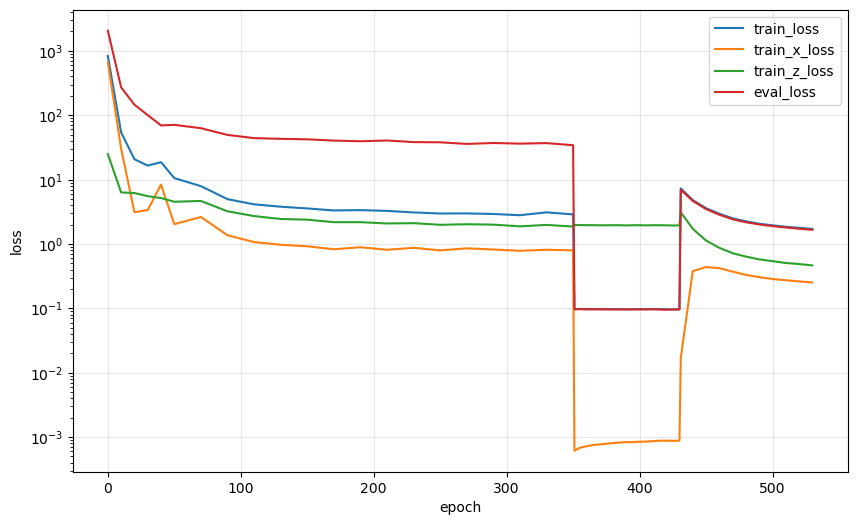

In [18]:
def history_to_numpy(values):
    """Convert history lists containing Python numbers, NumPy values, or Torch tensors to NumPy."""
    out = []
    for v in values:
        if isinstance(v, torch.Tensor):
            out.append(v.detach().cpu().item() if v.ndim == 0 else v.detach().cpu().numpy())
        else:
            out.append(v)
    return np.asarray(out, dtype=float)

epoch = history_to_numpy(history['epoch'])
train_loss = history_to_numpy(history['train_loss'])
train_x_loss = history_to_numpy(history['train_x_loss'])
train_z_loss = history_to_numpy(history['train_z_loss'])
eval_loss = history_to_numpy(history['eval_loss'])

fig = plt.figure(figsize=(10, 6))

plt.plot(epoch, train_loss, label='train_loss')
plt.plot(epoch, train_x_loss, label='train_x_loss')
plt.plot(epoch, train_z_loss, label='train_z_loss')
plt.plot(epoch, eval_loss, label='eval_loss')

plt.xlabel('epoch')
plt.ylabel('loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Show Results

## Get Results

In [19]:
#-- Reset random seeds --#
torch.manual_seed(seed)
np.random.seed(seed)

#-- Convert model to CPU and evaluation mode --#
model.to('cpu')
model.encoder.output_stats.to('cpu')
model.decoder.output_stats.to('cpu')
model.eval()

all_arrs = {'train': {}, 'val': {}, 'test': {}}
all_arrs['train']['x'] = x_train
all_arrs['train']['z'] = z_train
all_arrs['val']['x'] = x_val
all_arrs['val']['z'] = z_val
all_arrs['test']['x'] = x_test
all_arrs['test']['z'] = z_test

with torch.no_grad():
    for data_key in 'train', 'val', 'test':
        arrs = all_arrs[data_key]

        z_tensor = torch.from_numpy(arrs['z'])
        x_tensor = torch.from_numpy(arrs['x'])

        arrs['z_decoded'] = model.decode(z_tensor)
        arrs['x_encoded'] = model.encode(x_tensor)
        arrs['x_reconstructed'] = model.decode(arrs['x_encoded'])

        for field, arr in list(arrs.items()):
            if isinstance(arr, torch.Tensor):
                arrs[field] = arr.detach().cpu().numpy()

print('Generated arrays for:', list(all_arrs.keys()))
for key in ['x', 'z', 'x_reconstructed', 'z_decoded']:
    print(key, all_arrs['val'][key].shape)


Generated arrays for: ['train', 'val', 'test']
x (134468, 8)
z (62394, 8)
x_reconstructed (134468, 8)
z_decoded (62394, 8)


# Save Results

In [20]:
from pathlib import Path

# Save everything under saves/<dataset_name>/
save_dir = Path("saves") / dataset_name
save_dir.mkdir(parents=True, exist_ok=True)

# 1. Save state_dict weights
model_save_path = save_dir / "model_state_dict.pkl"
torch.save(model.state_dict(), model_save_path)
print("Saved model weights to", model_save_path)

# 2. Save full model object, so diagnostic notebooks can directly call model.encode(x)
full_model_save_path = save_dir / "model_full.pt"
torch.save(model, full_model_save_path)
print("Saved full model to", full_model_save_path)

# 3. Save test results
results_save_path = save_dir / "results_test.npz"
np.savez(results_save_path, **all_arrs["test"])
print("Model results saved at", results_save_path)

# 4. Save training history
history_save_path = save_dir / "history.npz"
history_np = {key: history_to_numpy(value) for key, value in history.items()}
np.savez(history_save_path, **history_np)
print("Training history saved at", history_save_path)

Saved model weights to saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v3_fullproduction\model_state_dict.pkl
Saved full model to saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v3_fullproduction\model_full.pt
Model results saved at saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v3_fullproduction\results_test.npz
Training history saved at saves\cms_doubleelectron_mg5_dyee_dy1j_ptj5_zcycle_v3_fullproduction\history.npz


# Validation Plots

CMS x        mean= 90.633, std=  5.866, peak= 91.750, frac_70_110= 1.000
x-z-x        mean= 90.386, std=  6.453, peak= 91.750, frac_70_110= 0.991
z-x          mean= 90.757, std=  6.225, peak= 91.750, frac_70_110= 0.991


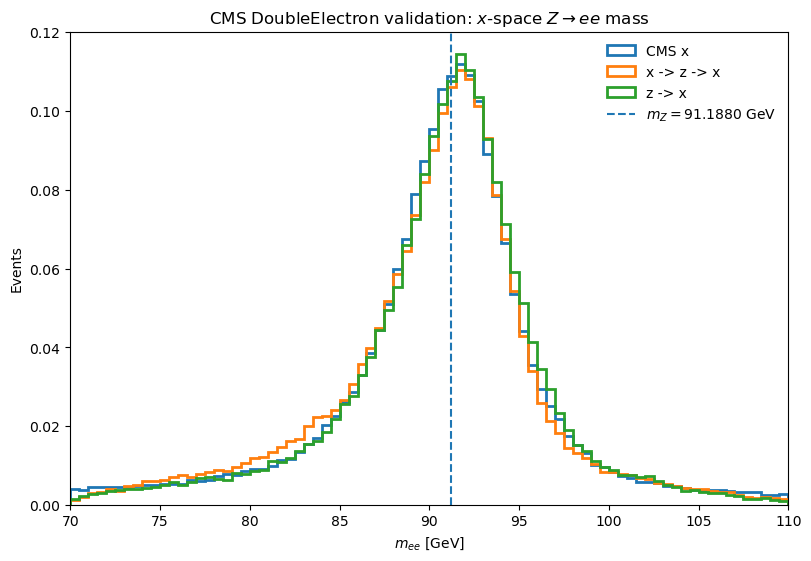


Residual check for z -> x vs CMS x, validation set:
mll central/stat-safe bins used: 80
mll max |relative residual|: 0.6238
mll RMS relative residual:   0.1924


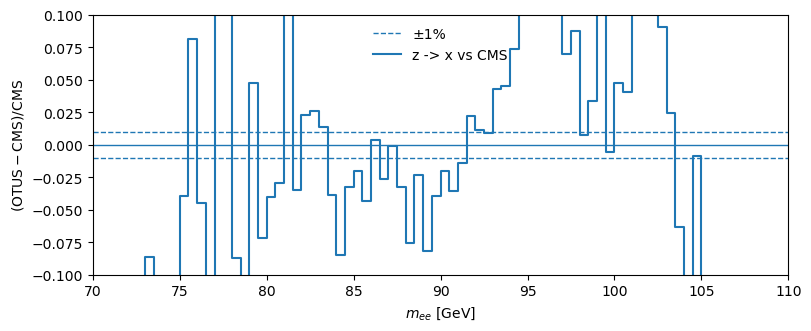

RMS residual is still above 1%. Keep v3 stages first; only switch HP["architecture_preset"] to "3x512_plateau_retry" if this plateaus after tuning residual weights.


In [ ]:
from func_utils import Zboson_mass

arrs = all_arrs['val']

m_x = Zboson_mass(arrs['x'])
m_rec = Zboson_mass(arrs['x_reconstructed'])
m_zdec = Zboson_mass(arrs['z_decoded'])

def summarize_mass(name, m):
    bins_summary = np.linspace(70, 110, 81)
    counts, edges = np.histogram(m, bins=bins_summary)
    peak = 0.5 * (edges[np.argmax(counts)] + edges[np.argmax(counts) + 1])
    print(
        f'{name:12s} '
        f'mean={np.mean(m):7.3f}, '
        f'std={np.std(m):7.3f}, '
        f'peak={peak:7.3f}, '
        f'frac_70_110={np.mean((m > 70) & (m < 110)):6.3f}'
    )

summarize_mass('CMS x', m_x)
summarize_mass('x-z-x', m_rec)
summarize_mass('z-x', m_zdec)

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
bins = np.linspace(70, 110, 81)

ax.hist(m_x, bins=bins, histtype="step", linewidth=2, density=True, label="CMS x")
ax.hist(m_rec, bins=bins, histtype="step", linewidth=2, density=True, label="x -> z -> x")
ax.hist(m_zdec, bins=bins, histtype="step", linewidth=2, density=True, label="z -> x")
ax.set_ylabel("Normalized density")
ax.axvline(91.1880, linestyle='--', linewidth=1.5, label=r'$m_Z = 91.1880$ GeV')

ax.set_xlabel(r'$m_{ee}$ [GeV]')
ax.set_ylabel('Normalized Density')
ax.set_xlim(70, 110)
ax.set_title(r'CMS DoubleElectron validation: $x$-space $Z\to ee$ mass')
ax.legend(frameon=False)
plt.show()


def relative_residual_summary(true_values, pred_values, bins, min_true_count=100):
    """Bin-by-bin normalized residual summary for checking 1% reach."""
    h_true, edges = np.histogram(true_values, bins=bins)
    h_pred, _ = np.histogram(pred_values, bins=bins)

    h_true_norm = h_true / max(1, np.sum(h_true))
    h_pred_norm = h_pred / max(1, np.sum(h_pred))

    mask = h_true >= min_true_count
    residual = np.full_like(h_true_norm, np.nan, dtype=float)
    residual[mask] = (h_pred_norm[mask] - h_true_norm[mask]) / np.maximum(h_true_norm[mask], 1e-12)

    return {
        'n_bins_used': int(np.sum(mask)),
        'max_abs_residual': float(np.nanmax(np.abs(residual))) if np.any(mask) else np.nan,
        'rms_residual': float(np.sqrt(np.nanmean(residual[mask] ** 2))) if np.any(mask) else np.nan,
        'residual': residual,
        'edges': edges,
        'mask': mask,
    }

mass_resid = relative_residual_summary(m_x, m_zdec, bins=np.linspace(70, 110, 81), min_true_count=100)
print('\nResidual check for z -> x vs CMS x, validation set:')
print(f"mll central/stat-safe bins used: {mass_resid['n_bins_used']}")
print(f"mll max |relative residual|: {mass_resid['max_abs_residual']:.4f}")
print(f"mll RMS relative residual:   {mass_resid['rms_residual']:.4f}")

fig, ax = plt.subplots(figsize=(8, 3.2), constrained_layout=True)
centers = 0.5 * (mass_resid['edges'][:-1] + mass_resid['edges'][1:])
ax.axhline(0.0, linewidth=1.0)
ax.axhline(0.01, linestyle='--', linewidth=1.0, label='±1%')
ax.axhline(-0.01, linestyle='--', linewidth=1.0)
ax.step(centers, mass_resid['residual'], where='mid', linewidth=1.5, label='z -> x vs CMS')
ax.set_xlabel(r'$m_{ee}$ [GeV]')
ax.set_ylabel(r'$(\mathrm{OTUS}-\mathrm{CMS})/\mathrm{CMS}$')
ax.set_ylim(-0.10, 0.10)
ax.set_xlim(70, 110)
ax.legend(frameon=False)
plt.show()

if mass_resid['rms_residual'] > 0.01:
    print('RMS residual is still above 1%. Keep v3 stages first; only switch HP["architecture_preset"] to "3x512_plateau_retry" if this plateaus after tuning residual weights.')
else:
    print('Mass RMS residual is at or below 1% in the stat-safe bins. Do not move to 3x512 unless other observables plateau.')


## Optional generator diagnostic: dilepton transverse momentum

A pure LO MG5 `pp -> e+ e-` prior has very small dilepton recoil before OTUS. This check helps diagnose whether the generated `z -> x` events learn CMS-like transverse recoil.

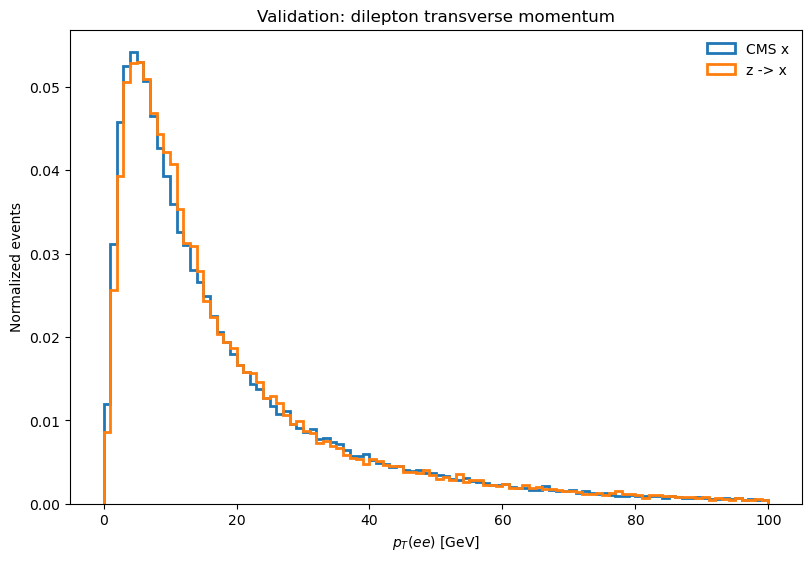

CMS pT(ee) mean:  20.6258 GeV
z -> x pT(ee) mean: 20.7223 GeV


In [22]:
def dilepton_pt(y):
    px = y[:, 0] + y[:, 4]
    py = y[:, 1] + y[:, 5]
    return np.sqrt(px**2 + py**2)

x_ptll = dilepton_pt(arrs['x'])
zdec_ptll = dilepton_pt(arrs['z_decoded'])

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
bins = np.linspace(0, 100, 101)

ax.hist(x_ptll, bins=bins, histtype='step', linewidth=2, density=True, label='CMS x')
ax.hist(zdec_ptll, bins=bins, histtype='step', linewidth=2, density=True, label='z -> x')

ax.set_xlabel(r'$p_T(ee)$ [GeV]')
ax.set_ylabel('Normalized events')
ax.set_title(r'Validation: dilepton transverse momentum')
ax.legend(frameon=False)
plt.show()

print(f'CMS pT(ee) mean:  {np.mean(x_ptll):.4f} GeV')
print(f'z -> x pT(ee) mean: {np.mean(zdec_ptll):.4f} GeV')


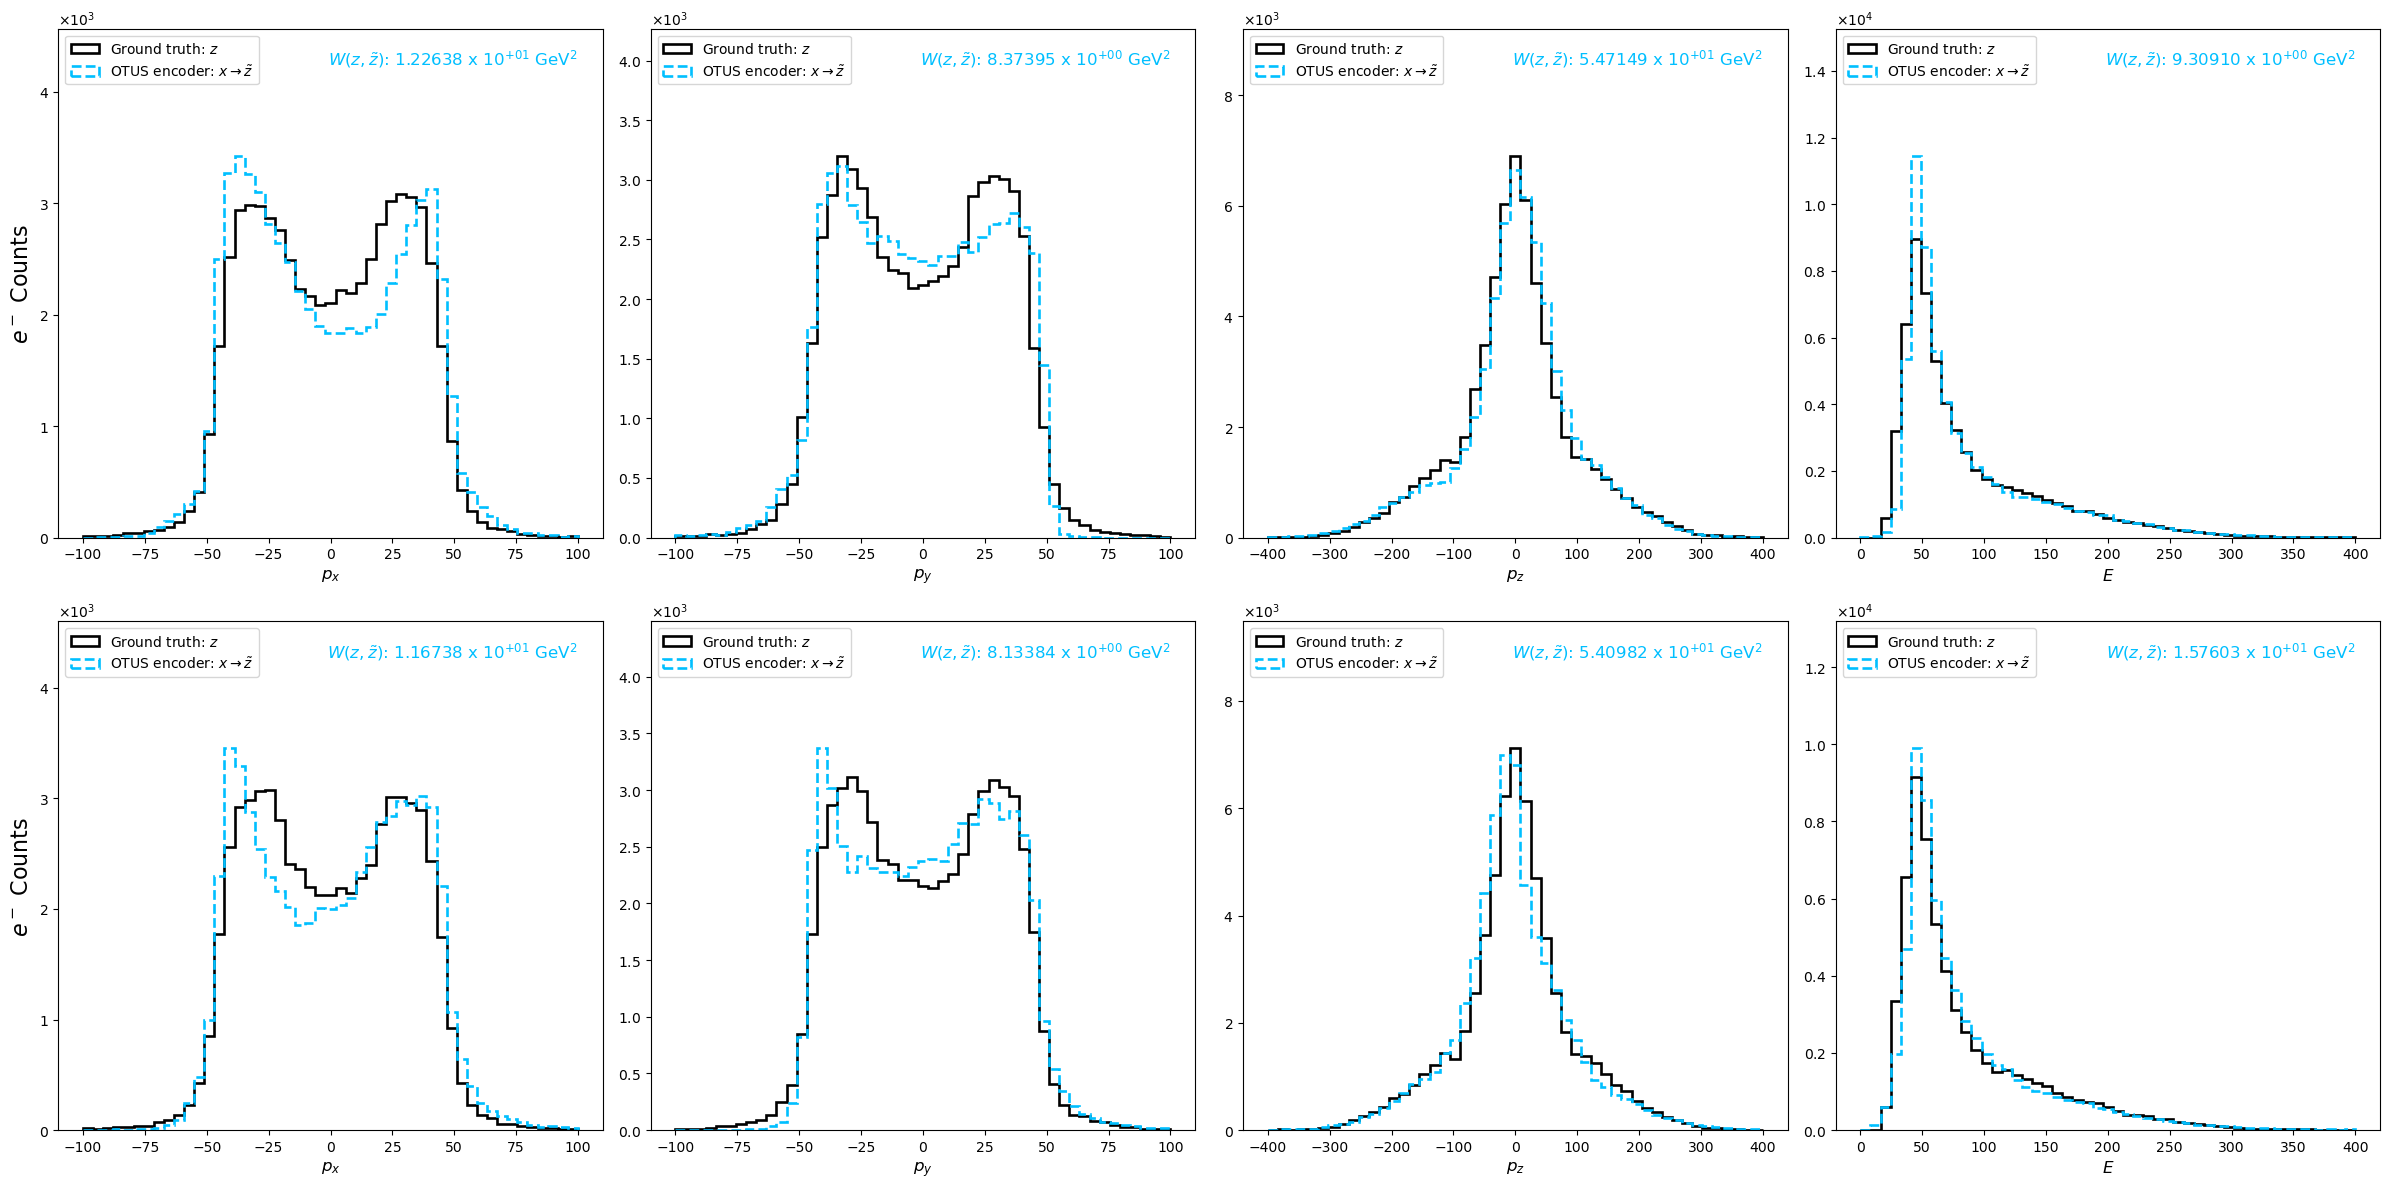

In [23]:
from plot_utils import plotFunction

dataList = [arrs['z'], arrs['x_encoded']]
pltDim = (2, 4)
numBins = 50
binsList = [np.linspace(-100., 100., numBins),
            np.linspace(-100., 100., numBins),
            np.linspace(-400., 400., numBins),
            np.linspace(0., 400., numBins),
            np.linspace(-100., 100., numBins),
            np.linspace(-100., 100., numBins),
            np.linspace(-400., 400., numBins),
            np.linspace(0., 400., numBins)]
particleNameList = [r'$e^-$'] * 4 + [r'$e^+$'] * 4
nameList = [r'$p_x$', r'$p_y$', r'$p_z$', r'$E$', r'$p_x$', r'$p_y$', r'$p_z$', r'$E$']

plotFunction(dataList=dataList, pltDim=pltDim, binsList=binsList,
             particleNameList=particleNameList, nameList=nameList)

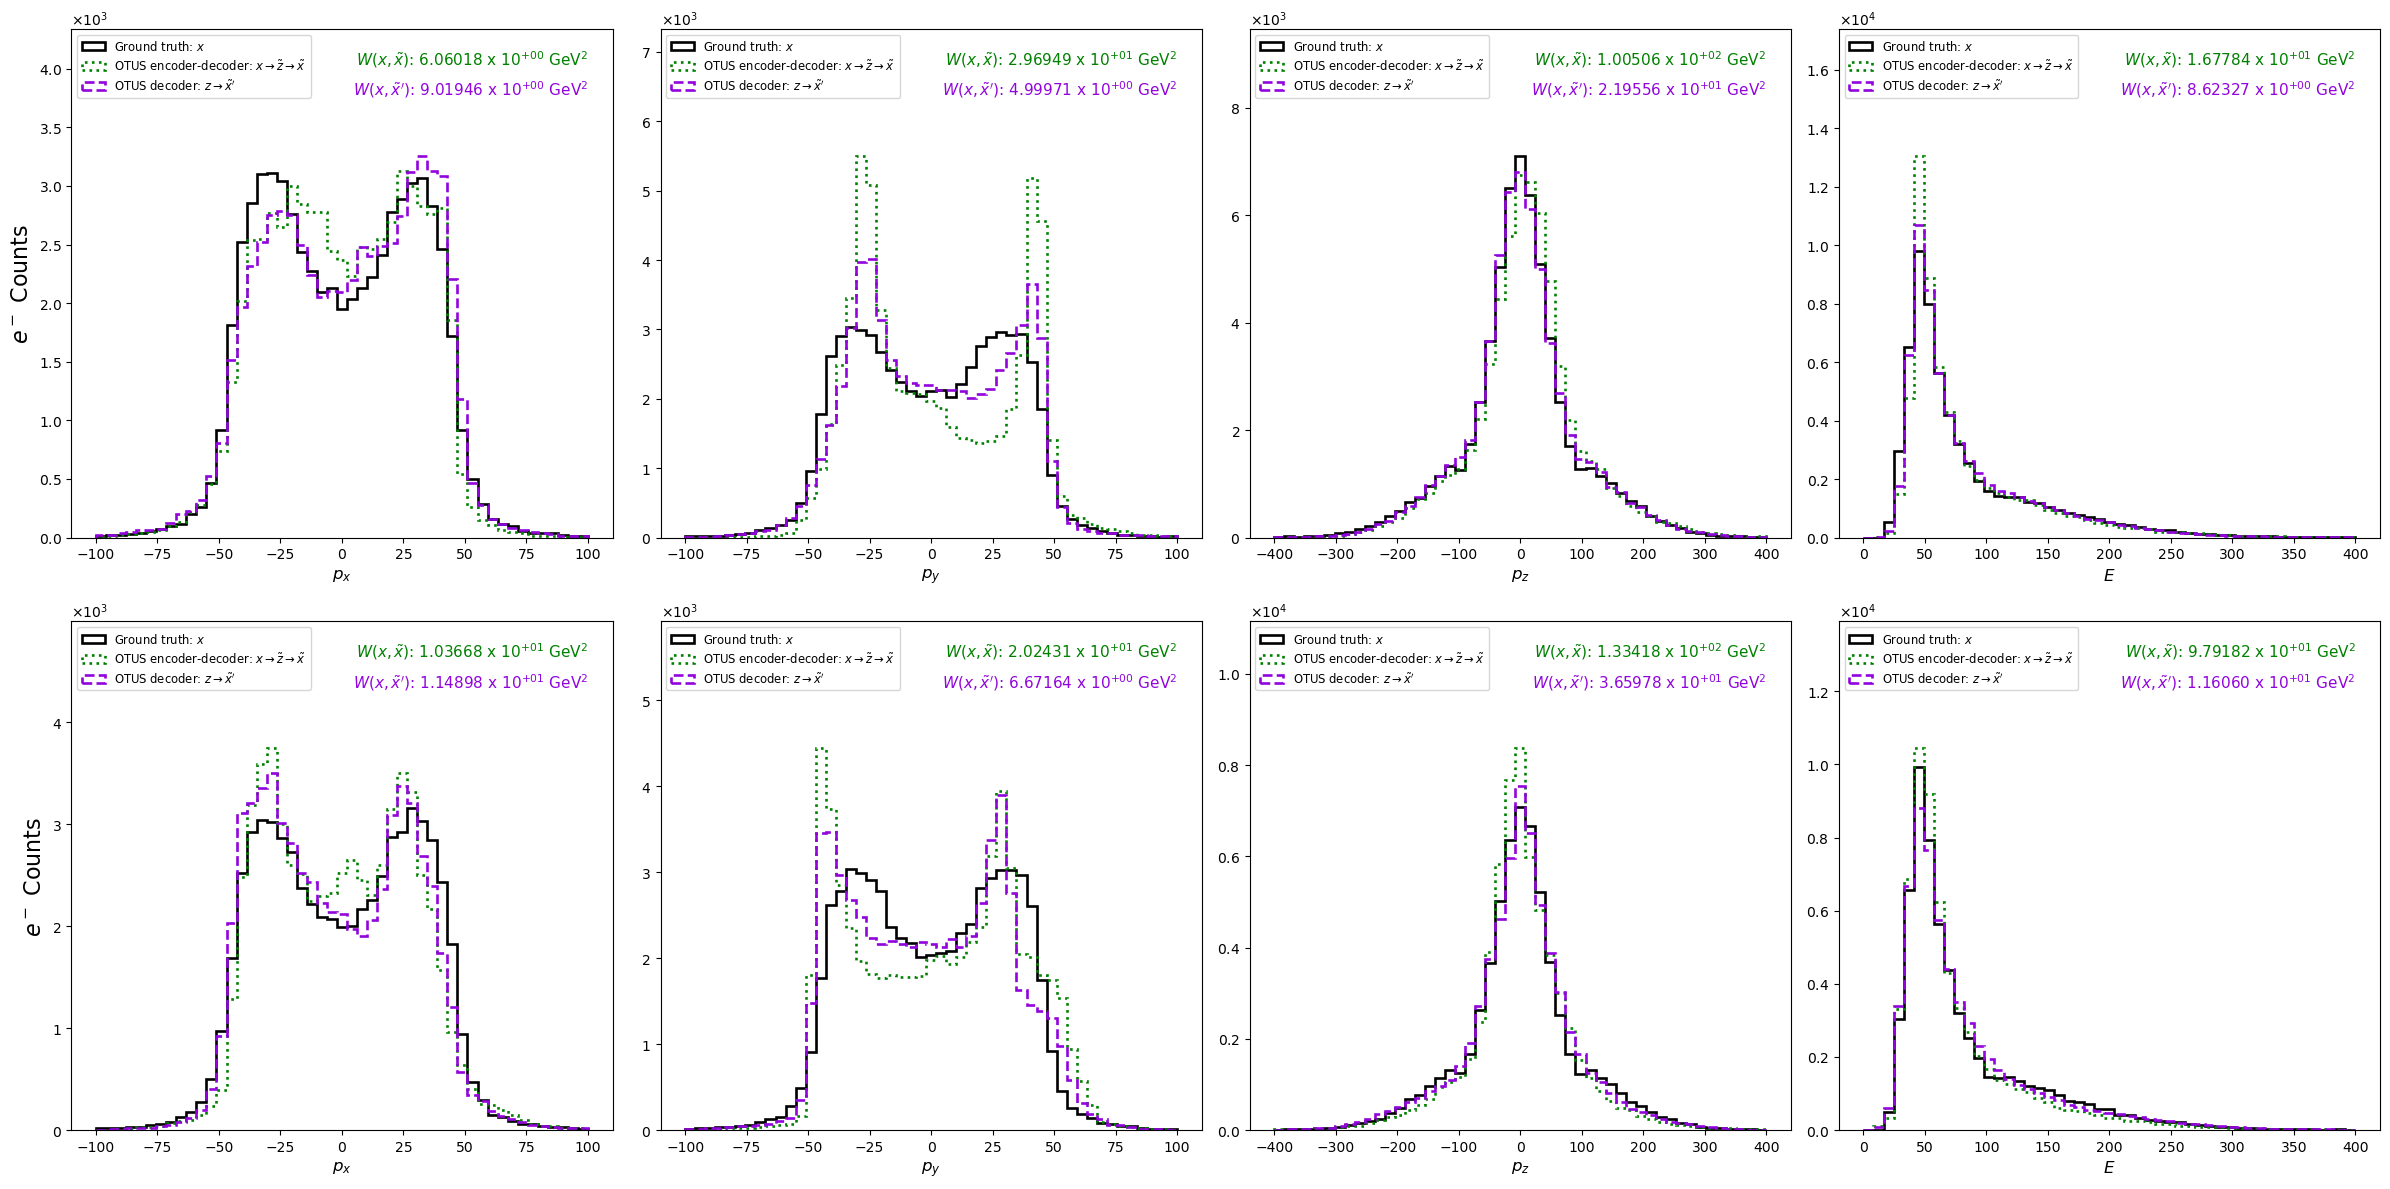

In [24]:
dataList = [arrs['x'], arrs['x_reconstructed'], arrs['z_decoded']]

plotFunction(dataList=dataList, pltDim=pltDim, binsList=binsList,
             particleNameList=particleNameList, nameList=nameList)

In [25]:
def repeated_encoded_mass(model, x_np, n_repeat=10, n_eval=20000):
    model.eval()
    x_small = torch.from_numpy(x_np[:n_eval]).to('cpu')

    masses = []
    with torch.no_grad():
        for _ in range(n_repeat):
            z_hat = model.encode(x_small)
            z_hat_np = z_hat.detach().cpu().numpy()
            masses.append(Zboson_mass(z_hat_np))

    masses = np.stack(masses, axis=0)
    return masses

m_repeats = repeated_encoded_mass(model, x_val, n_repeat=10, n_eval=20000)

print("Mean over stochastic samples:", np.mean(m_repeats))
print("Std of all stochastic samples:", np.std(m_repeats))
print("Average per-event stochastic mass std:", np.mean(np.std(m_repeats, axis=0)))

Mean over stochastic samples: 91.20061
Std of all stochastic samples: 4.0885797
Average per-event stochastic mass std: 0.00017542375


In [26]:
# check decoder stochasticity
def repeated_decoded_mass_from_z(model, z_np, n_repeat=10, n_eval=20000):
    model.eval()
    z_small = torch.from_numpy(z_np[:n_eval]).to('cpu')

    masses = []
    with torch.no_grad():
        for _ in range(n_repeat):
            x_hat = model.decode(z_small)
            x_hat_np = x_hat.detach().cpu().numpy()
            masses.append(Zboson_mass(x_hat_np))

    masses = np.stack(masses, axis=0)
    return masses

m_dec_repeats = repeated_decoded_mass_from_z(model, z_val, n_repeat=10, n_eval=20000)

print("z->x mean over samples:", np.mean(m_dec_repeats))
print("z->x std of all samples:", np.std(m_dec_repeats))
print("z->x average per-event stochastic mass std:", np.mean(np.std(m_dec_repeats, axis=0)))

z->x mean over samples: 90.74222
z->x std of all samples: 6.2781677
z->x average per-event stochastic mass std: 0.00093291304
